# Demo 05: Fine-tune EpiZoo for data imputation

This notebook demonstrates how to fine-tune **EpiZoo** and get **EpiZooDI** for data imputation task.

Starting from a pretrained EpiZoo model, users can fine-tune the model to their own scATAC-seq data. After fine-tuning, EpiZooAnno can be used to impute scATAC-seq data.

## Required files

Before running this notebook, please prepare the following files:

- **`model.pth`**: The pretrained EpiZoo model checkpoint. (The pretrained EpiZoo checkpoint can be downloaded at [pretrained_EpiZoo.pth](https://drive.google.com/file/d/1Xs5R_LAMbB_Zqpg7SFHlrAMfVcdcGwVE/view?usp=drive_link))

## Output

This notebook will generate:

- A fine-tuned EpiZooDI model checkpoint
- Imputed data matrix
- Metrics and visualization of the data imputation task

In [1]:
import os
import sys

# Add EpiZoo root directory
PROJECT_ROOT = os.path.abspath("../")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Step 1: Data processing

To prepare dataset for EpiZoo, we perform the following preprocessing steps:

1. **Random dropout simulation:** Randomly mask 50% accessible cCREs from the original chromatin accessibility profiles.

2. **TF-IDF transformation:** Convert the raw count matrix into TF-IDF normalized values, which quantify the relative importance of accessible cCREs within each cell.

3. **Cell sentence generation:** Rank accessible cCREs according to their TF-IDF scores and convert each cell into a compact cell sentence composed of cCRE indices, which serves as the input for EpiZoo.

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, issparse

# Load the dataset
adata_file_path = "../data/Fang2021_downsampled_2000_cells.h5ad"
adata = sc.read_h5ad(adata_file_path)
print(f"Anndata: {adata}")

# Ensure CSR sparse matrix format
if not issparse(adata.X):
    adata.X = csr_matrix(adata.X)
else:
    adata.X = adata.X.tocsr()

adata_dropped = adata.copy()

# Randomly remove 50% of accessible cCREs
nnz_original = adata_dropped.X.nnz
drop_count = int(nnz_original * 0.5)

# Randomly select non-zero entries to drop
drop_indices = np.random.choice(
    nnz_original, 
    size=drop_count, 
    replace=False
)

# Set selected entries to zero
adata_dropped.X.data[drop_indices] = 0

# Remove zero entries from sparse matrix structure
adata_dropped.X.eliminate_zeros()

# Report dropout statistics
nnz_new = adata_dropped.X.nnz
print(f"Original non-zero entries: {nnz_original:,}")
print(f"Remaining after dropout: {nnz_new:,} ({nnz_new / nnz_original:.2%} retained)")

Anndata: AnnData object with n_obs × n_vars = 2000 × 1341077
    obs: 'prefix_barcode', 'sample name', 'barcode', 'tsne1', 'tsne2', 'celltype', 'celltype2', 'batch', 'dataset'
Original non-zero entries: 6,703,562
Remaining after dropout: 3,351,781 (50.00% retained)


In [3]:
from epizoo.data.processing import compute_tfidf, filter_cCREs, generate_cell_sentences

# Load the cCRE document frequency data (for mouse here)
df_file_path = "../data/cCRE_frequencies_mouse.npy"
df = np.load(df_file_path)
print(f"Document Frequency: {df}")

# Load the cCRE filter index (for mouse here)
filter_index_file_path = "../data/cCRE_filter_idx_mouse.csv"
filter_index = pd.read_csv(filter_index_file_path,index_col=0)['idx'].values
print(f"Filter Index: {filter_index}")

# Preprocess the data
# Perform TF-IDF transformation
adata = compute_tfidf(adata, df, cell_number=12500000)
adata_dropped = compute_tfidf(adata_dropped, df, cell_number=12500000)

# Filter cCRE
adata = filter_cCREs(adata, filter_idx=filter_index, species=1)
adata_dropped = filter_cCREs(adata_dropped, filter_idx=filter_index, species=1)

# Generate cell sentences
adata_dropped = generate_cell_sentences(adata_dropped, species=1, species_offset=700460)
print(f"Cell Sentences:\n{adata_dropped.obs['cell_indices'][:5]}")

/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Document Frequency: [ 9086. 20040. 10906. ...  1046.  1051.  3763.]
Filter Index: [      3       4       8 ... 1341044 1341059 1341062]
TF-IDF completed. TF-IDF matrix stored in adata.X
Matrix shape: (2000, 1341077)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Data type: float32
Non-zero entries: 6,703,562
Sparsity: 99.7501%
Non-zero value min: 0.470534
Non-zero value max: 329.738953
Non-zero value mean: 12.603610
Non-zero value median: 8.776130
--------------------------------------------------
Accessible cCREs per cell:
  Mean: 3351.78
  Median: 2422.00
  Min: 494
  Max: 24220
TF-IDF completed. TF-IDF matrix stored in adata.X
Matrix shape: (2000, 1341077)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Data type: float32
Non-zero entries: 3,351,781
Sparsity: 99.8750%
Non-zero value min: 0.944199
Non-zero value max: 662.831116
Non-zero value mean: 25.201813
Non-zero value median: 17.549940
--------------------------------------------------
Accessible cCREs per cell:
  Mean:

## Step 2: Create Dataset and DataLoader

After generating cell sentences, we construct `CellDatasetDI` and DataLoader for model fine-tuning. Each cell is represented as a sequence of tokens with special tokens [CLS] and [SEP].

In [4]:
from epizoo.data.datasets import CellDatasetDI, collate_fn, InferenceCellDataset, inference_collate_fn
from torch.utils.data import DataLoader

# Create a dataset and dataloader for fine-tuning
human_vocab_size = 700460
mouse_vocab_size = 814020
celldataset = CellDatasetDI(
    adata=adata_dropped,
    cell_sentences=adata_dropped.obs['cell_indices'].values,
    species=1,
    cca_alpha=1,
    human_num_ccres=human_vocab_size,
    mouse_num_ccres=mouse_vocab_size,
)
dataloader = DataLoader(
    celldataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
)

# Create a dataset and dataloader for inference
inference_dataset = InferenceCellDataset(
    cell_sentences=adata_dropped.obs['cell_indices'].values,
    species=[1] * adata_dropped.n_obs,
)
inference_dataloader = DataLoader(
    inference_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=inference_collate_fn,
)

## Step 3: Load the pretrained EpiZoo model

We load the pretrained model checkpoint for fine-tuning.

In [5]:
import torch
from epizoo.models.epizoo import EpiZooConfig
from epizoo.models.epizoo_di import EpiZooDI

# Load pretrained model
model_path = "/data/lizhen/epizoo/models/pretrained_EpiZoo.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Initialize EpiZoo model
config = EpiZooConfig(
    vocab_size = human_vocab_size + mouse_vocab_size + 4,
    human_vocab_size = human_vocab_size,
    mouse_vocab_size = mouse_vocab_size,
    num_layers = 30,
)
model = EpiZooDI(cfg=config)

# Load pretrained weights
state_dict = torch.load(model_path, map_location="cpu")
msg = model.load_state_dict(state_dict, strict=False)

print("=" * 80)
print("Missing keys (new in EpiZooDI):")
if len(msg.missing_keys) == 0:
    print("None")
else:
    for k in msg.missing_keys:
        print(f"  {k}")
print("Unexpected keys (not used in EpiZooDI):")
if len(msg.unexpected_keys) == 0:
    print("None")
else:
    for k in msg.unexpected_keys:
        print(f"  {k}")
print("=" * 80)
print(f"Total missing keys: {len(msg.missing_keys)}")
print(f"Total unexpected keys: {len(msg.unexpected_keys)}")

# Move model to device
model = model.to(device)

print("EpiZooDI model loaded successfully.")

Missing keys (new in EpiZooDI):
  cca_loss_fn.pos_weight
Unexpected keys (not used in EpiZooDI):
None
Total missing keys: 1
Total unexpected keys: 0
EpiZooDI model loaded successfully.


## Step 4: Model fine-tuning

We fine-tune the pretrained EpiZoo model on the new scATAC-seq dataset using `EpiZooFinetuneTrainer`.

The fine-tuned model checkpoint will be saved for downstream inference.

In [6]:
from epizoo.train.finetune import EpiZooFinetuneTrainer, FineTuneConfig, LoRAConfig

# Fine-tuning configuration
ft_cfg = FineTuneConfig(
    mode="sr_cca",
    output_dir="/data/lizhen/epizoo/models/finetuned_model_di",
    max_steps=1000,
    save_steps=200,
    log_steps=100,
    keep_last=2,
    lr=5e-5,
    warmup_steps=100,
    device=device,
)

# Optional LoRA configuration
# Set all False for full parameter fine-tuning
lora_cfg = LoRAConfig(
    use_embedding=False,
    use_transformer=False,
    use_decoder=False,
)

trainer = EpiZooFinetuneTrainer(
    model=model,
    train_loader=dataloader,
    cfg=ft_cfg,
    lora_cfg=lora_cfg,
)

# Start fine-tuning
finetuned_model = trainer.train()

print(
    "This demo demonstrates the data imputation workflow only. "
    "In practice, sufficient training steps are required."
)

Frozen seq_emb.
Total parameters:     2,615,692,905
Trainable parameters: 1,840,277,097
Frozen parameters:    775,415,808


/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Step 100 | lr=5.000e-05 | loss=5.6030 | sr=5.0866 | cca=0.5164 | cca_pos_acc=0.7075 | cca_neg_acc=0.7819 | auroc=0.8140 | auprc=0.8297
Step 200 | lr=5.000e-05 | loss=2.7035 | sr=2.2023 | cca=0.5013 | cca_pos_acc=0.7166 | cca_neg_acc=0.7981 | auroc=0.8323 | auprc=0.8393
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model_di/202607150518_200.pth
Step 300 | lr=5.000e-05 | loss=2.5467 | sr=2.0510 | cca=0.4958 | cca_pos_acc=0.7355 | cca_neg_acc=0.8039 | auroc=0.8358 | auprc=0.8514
Step 400 | lr=5.000e-05 | loss=2.6379 | sr=2.1533 | cca=0.4847 | cca_pos_acc=0.7621 | cca_neg_acc=0.8012 | auroc=0.8522 | auprc=0.9351
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model_di/202607150520_400.pth
Step 500 | lr=4.500e-05 | loss=2.4955 | sr=2.0193 | cca=0.4762 | cca_pos_acc=0.7567 | cca_neg_acc=0.8320 | auroc=0.8667 | auprc=0.8833
Epoch 1 finished. Time: 348.65s
Step 600 | lr=4.500e-05 | loss=2.4877 | sr=2.0154 | cca=0.4723 | cca_pos_acc=0.7620 | cca_neg_acc=0.7884 | auroc=0.8510

## Step 5: Predict signals using the fine-tuned model

We use the `predict_signals` function to predict signals using the fine-tuned model.

In [7]:
from epizoo.inference.signals import predict_signals

# Predict signals
predicted_signals = predict_signals(
    finetuned_model,
    inference_dataloader,
    device=device,
    return_cell_emb=False,
)["predicted_signals"]

print(f"Completed. Predicted signals shape: {predicted_signals.shape}")

Predicting signals: 100%|██████████| 63/63 [00:20<00:00,  3.12it/s]


Completed. Predicted signals shape: (2000, 814020)


## Step 6: Metrics and visualization

We calculate imputation metrics and visualize the imputed chromatin accessibility landscape. In this demo, we select the **50,000 most accessible cCREs** from the original dataset for evaluation.

In [8]:
# Compute the overall accessibility for each cCRE by summing across all cells.
cCRE_accessibility = np.array(adata.X.sum(axis=0)).squeeze()

# Get the indices for the top 50,000 most accessible cCREs.
top_50000_indices = np.argsort(cCRE_accessibility)[-50000:]
adata_gt = adata[:, top_50000_indices].copy()

# Create the imputed AnnData object
adata_imputed = sc.AnnData(predicted_signals[:, top_50000_indices])
adata_imputed.obs['celltype'] = adata_gt.obs['celltype'].tolist()

Correlation summary:
--------------------------------------------------------------------------------
        metric     n  n_valid   mean median    std     min    max
cell_type_corr  2000     2000 0.6570 0.6466 0.1152  0.2007 0.8700
     cell_corr  2000     2000 0.1357 0.1288 0.0483  0.0371 0.3646
  feature_corr 50000    50000 0.0895 0.0852 0.0520 -0.0790 0.3729
--------------------------------------------------------------------------------


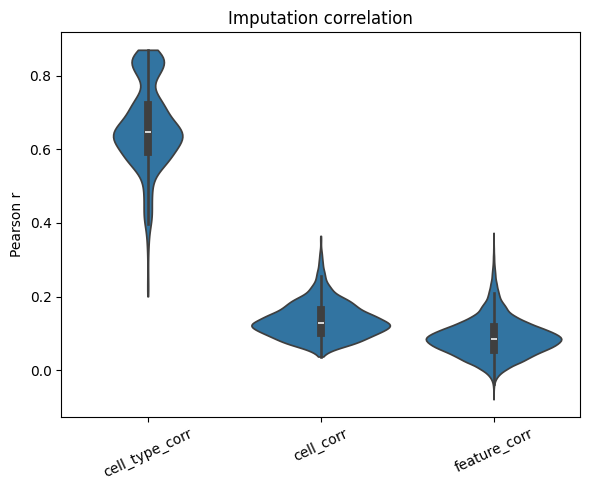

<Axes: title={'center': 'Imputation correlation'}, ylabel='Pearson r'>

In [9]:
from epizoo.metrics.correlations import compute_imputation_correlations
from epizoo.visualization.violin import plot_correlation_violin

# Compute correlations and summary statistics
correlations, summary = compute_imputation_correlations(
    adata_gt,
    adata_imputed,
    cell_type_key="celltype",
)

print("Correlation summary:")
print("-" * 80)
print(
    summary.to_string(
        index=False,
        formatters={
            "mean": "{:.4f}".format,
            "median": "{:.4f}".format,
            "std": "{:.4f}".format,
            "min": "{:.4f}".format,
            "max": "{:.4f}".format,
        },
    )
)
print("-" * 80)

# Plot correlation violin plots
plot_correlation_violin(
    correlations=correlations,
    show=True,
    figsize=(6,5),
)

Running Louvain clustering...
resolution=1.0, NMI=0.7435, ARI=0.6012, Homo=0.7009, AMI=0.7371
resolution=2.0, NMI=0.7342, ARI=0.6331, Homo=0.7192, AMI=0.7262
Louvain clustering with binary search
resolution=2.578125, NMI=0.7220, ARI=0.5683, Homo=0.7308, AMI=0.7123
Optimized clustering against `celltype`.
Best resolution: 1.0
Best NMI: 0.7435
NMI=0.7435, ARI=0.6012, Homo=0.7009, AMI=0.7371


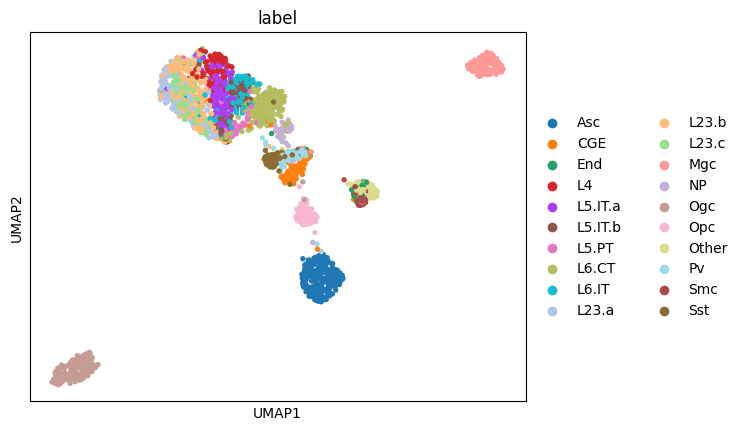

In [10]:
from epizoo.metrics.cluster import run_louvain
from epizoo.visualization import run_umap

# Compute PCA on the imputed data
sc.tl.pca(adata_imputed, n_comps=50)
sc.pp.neighbors(adata_imputed, n_neighbors=15)

# Perform Louvain clustering on the imputed data
run_louvain(
    adata_imputed,
    label_key='celltype',
)

# Run UMAP on the imputed data
adata = run_umap(
    adata_imputed.obsm['X_pca'],
    labels=adata_imputed.obs['celltype'].values,
    label_key="label",
    output_file=None,
    n_neighbors=15,
    random_state=2020,
    show=True,
)